In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd

path = "/content/drive/MyDrive/Colab Notebooks/phase3/"

airports = pd.read_csv(path + "airports.csv")
countries = pd.read_csv(path + "countries.csv")
regions = pd.read_csv(path + "regions.csv")
delays = pd.read_csv(path + "flight_delays.csv")

print("Files loaded successfully")

Files loaded successfully


In [31]:
print("Airports Shape:", airports.shape)
print("Delays Shape:", delays.shape)

Airports Shape: (85451, 19)
Delays Shape: (5000, 24)


In [32]:
print(delays.columns.tolist())

['Year', 'Month', 'Day', 'DayOfWeek', 'Flight_Date', 'UniqueCarrier', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time', 'Dep_Delay', 'DepDel15', 'Scheduled_Arrival', 'Arrival_Delay', 'Arr_Del_morethan15', 'Distance', 'DistanceGroup', 'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay', 'Late_Aircraft_Delay', 'DEPTIME_GROUP1', 'DEPTIME_GROUP2', 'DEPTIME_GROUP3']


# Dataset Description

## Airport Dataset

The airport dataset was collected from the OurAirports website.

It contains information about airports around the world such as:
- Airport name
- Country
- Latitude and longitude
- Airport type
- Elevation

The following files were used:
- airports.csv
- countries.csv
- regions.csv

---

## Flight Delay Dataset

The flight delay dataset contains information about flights and delays.

The dataset includes:
- Flight information
- Airport codes
- Airline information
- Delay data

The dataset will later be used for preprocessing, analysis, and prediction.

---

## Selected Countries

I selected the following countries from the dataset:

* United States (US)
* United Kingdom (GB)
* New Zealand (NZ)
* Australia (AU)
* Germany (DE)

These countries were selected because they are available in the `iso_country` column of the dataset.

Using countries that already exist in the dataset ensures:

* No invalid or missing filters occur during preprocessing
* The analysis remains consistent with the available data
* The results can be reproduced without errors

Additionally, these countries provide geographic diversity across North America, Europe, and Oceania, which helps create a broader analysis of airport and flight delay data.


In [ ]:
print("Airports Dataset")
print(airports.head())

print("\nFlight Delays Dataset")
print(delays.head())

Airports Dataset
       id ident           type                  name  latitude_deg  \
0    6523   00A       heliport     Total RF Heliport     40.070985   
1  323361  00AA  small_airport  Aero B Ranch Airport     38.704022   
2    6524  00AK  small_airport          Lowell Field     59.947733   
3    6525  00AL  small_airport          Epps Airpark     34.864799   
4  506791  00AN  small_airport  Katmai Lodge Airport     59.093287   

   longitude_deg  elevation_ft continent iso_country iso_region  municipality  \
0     -74.933689          11.0       NaN          US      US-PA      Bensalem   
1    -101.473911        3435.0       NaN          US      US-KS         Leoti   
2    -151.692524         450.0       NaN          US      US-AK  Anchor Point   
3     -86.770302         820.0       NaN          US      US-AL       Harvest   
4    -156.456699          80.0       NaN          US      US-AK   King Salmon   

  scheduled_service icao_code iata_code gps_code local_code  \
0           

In [33]:
print("\nAirports Info")
airports.info()

print("\nDelays Info")
delays.info()


Airports Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85451 entries, 0 to 85450
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 85451 non-null  int64  
 1   ident              85451 non-null  object 
 2   type               85451 non-null  object 
 3   name               85451 non-null  object 
 4   latitude_deg       85451 non-null  float64
 5   longitude_deg      85451 non-null  float64
 6   elevation_ft       70614 non-null  float64
 7   continent          45879 non-null  object 
 8   iso_country        85148 non-null  object 
 9   iso_region         85451 non-null  object 
 10  municipality       80745 non-null  object 
 11  scheduled_service  85451 non-null  object 
 12  icao_code          10045 non-null  object 
 13  iata_code          9058 non-null   object 
 14  gps_code           44241 non-null  object 
 15  local_code         36072 non-null  object 
 16  home_li

In [ ]:
selected_countries = ['US', 'GB', 'NZ', 'AU', 'DE']

filtered_airports = airports[
    airports['iso_country'].isin(selected_countries)
]

print(filtered_airports['iso_country'].value_counts())

iso_country
US    32510
AU     2789
GB     1593
DE     1431
NZ      319
Name: count, dtype: int64


# Data Cleaning


In [ ]:
# =========================
# Missing Values
# =========================

print("Missing Values in Airports")
print(airports.isnull().sum())

print("\nMissing Values in Delays")
print(delays.isnull().sum())

Missing Values in Airports
id                       0
ident                    0
type                     0
name                     0
latitude_deg             0
longitude_deg            0
elevation_ft         14837
continent            39572
iso_country            303
iso_region               0
municipality          4706
scheduled_service        0
icao_code            75406
iata_code            76393
gps_code             41210
local_code           49379
home_link            80748
wikipedia_link       68757
keywords             64118
dtype: int64

Missing Values in Delays
Year                   0
Month                  0
Day                    0
DayOfWeek              0
Flight_Date            0
UniqueCarrier          0
Origin_Airport         0
Scheduled_Departure    0
Departure_Time         0
Dep_Delay              0
DepDel15               0
Scheduled_Arrival      0
Arrival_Delay          0
Arr_Del_morethan15     0
Distance               0
DistanceGroup          0
Carrier_Delay        

Missing values ​​in the airport and flight datasets were checked using the isnull().sum() function. This step aimed to identify columns containing missing data in order to process and improve data quality before starting the analysis and model building process.

In [ ]:
airports = airports.dropna(
    subset=['iata_code', 'iso_country']
)

Records containing missing values ​​in the iata_code and iso_country columns were deleted using the dropna() function. These two columns were considered essential to the project because the airport code is used for linking datasets, while the country information is used for filtering and analyzing target countries.

In [ ]:
# =========================
# Duplicate Values
# =========================

print("Duplicate rows in Airports:")
print(airports.duplicated().sum())

print("\nDuplicate rows in Delays:")
print(delays.duplicated().sum())

Duplicate rows in Airports:
0

Duplicate rows in Delays:
0


The data was checked for duplicate rows using the duplicated().sum() function. This step helps detect duplicate records that may affect the accuracy of the statistical analysis and the results of the predictive models.

In [ ]:
# Remove duplicates
airports = airports.drop_duplicates()

delays = delays.drop_duplicates()

The results showed no duplicate rows in either dataset, so no records were actually deleted; however, the deduplication step was included to ensure data quality.

In [ ]:
# =========================
# Data Types
# =========================

print(delays.dtypes)

Year                    int64
Month                   int64
Day                     int64
DayOfWeek               int64
Flight_Date            object
UniqueCarrier          object
Origin_Airport         object
Scheduled_Departure     int64
Departure_Time          int64
Dep_Delay               int64
DepDel15                int64
Scheduled_Arrival       int64
Arrival_Delay           int64
Arr_Del_morethan15      int64
Distance                int64
DistanceGroup           int64
Carrier_Delay           int64
WeatherDelay            int64
NAS_Delay               int64
Security_Delay          int64
Late_Aircraft_Delay     int64
DEPTIME_GROUP1         object
DEPTIME_GROUP2         object
DEPTIME_GROUP3         object
dtype: object


In [ ]:
# Convert Flight_Date to datetime

delays['Flight_Date'] = pd.to_datetime(
    delays['Flight_Date']
)

/tmp/ipykernel_735/930938792.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  delays['Flight_Date'] = pd.to_datetime(


The Flight_Date column was converted from a string to a date and time column using the pd.to_datetime() function. This step enables advanced time operations such as extracting the year, month, and day, and analyzing time patterns related to flight delays.

In [ ]:
print(delays.dtypes)

Year                            int64
Month                           int64
Day                             int64
DayOfWeek                       int64
Flight_Date            datetime64[ns]
UniqueCarrier                  object
Origin_Airport                 object
Scheduled_Departure             int64
Departure_Time                  int64
Dep_Delay                       int64
DepDel15                        int64
Scheduled_Arrival               int64
Arrival_Delay                   int64
Arr_Del_morethan15              int64
Distance                        int64
DistanceGroup                   int64
Carrier_Delay                   int64
WeatherDelay                    int64
NAS_Delay                       int64
Security_Delay                  int64
Late_Aircraft_Delay             int64
DEPTIME_GROUP1                 object
DEPTIME_GROUP2                 object
DEPTIME_GROUP3                 object
dtype: object


In [ ]:
# =========================
# Remove Invalid Values
# =========================

delays = delays[
    delays['Arrival_Delay'] >= 0
]

print(delays.shape)

(2203, 24)


The data was filtered based on the Arrival_Delay column and only records with values ​​greater than or equal to zero were retained, in order to prepare the data for subsequent analysis.

In [ ]:
print(airports.columns)

Index(['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg',
       'elevation_ft', 'continent', 'iso_country', 'iso_region',
       'municipality', 'scheduled_service', 'icao_code', 'iata_code',
       'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords'],
      dtype='object')


In [ ]:
selected_countries = ['US', 'GB', 'NZ', 'AU', 'DE']

filtered_airports = airports[
    airports['iso_country'].isin(selected_countries)
]

print(filtered_airports['iso_country'].value_counts())

iso_country
US    2035
AU     612
GB      99
DE      85
NZ      58
Name: count, dtype: int64


In [ ]:
# =========================
# Merge Datasets
# =========================

merged_df = pd.merge(
    delays,
    filtered_airports,
    left_on='Origin_Airport',
    right_on='iata_code',
    how='inner'
)

print(merged_df.shape)

print(merged_df.head())

(5000, 43)
   Year  Month  Day  DayOfWeek Flight_Date UniqueCarrier Origin_Airport  \
0  2017      5   15          1  2017-05-15            DL            DFW   
1  2017      5   15          1  2017-05-15            DL            MSP   
2  2017      5   15          1  2017-05-15            DL            ATL   
3  2017      5   15          1  2017-05-15            DL            MSP   
4  2017      5   15          1  2017-05-15            DL            DEN   

   Scheduled_Departure  Departure_Time  Dep_Delay  ...  iso_region  \
0                 1605            1600         -5  ...       US-TX   
1                  700             656         -4  ...       US-MN   
2                 2147            2147          0  ...       US-GA   
3                 1756            1757          1  ...       US-MN   
4                  600             646         46  ...       US-CO   

        municipality  scheduled_service  icao_code  iata_code  gps_code  \
0  Dallas-Fort Worth                yes   

Flight data was merged with airport data using the `pd.merge()` function to add additional airport information such as country, geographic location, elevation, and airport type. The merge was performed using the airport code (`Origin_Airport` and `iata_code`) and the `Inner Join` method to retain only the records that matched in the two datasets. The merge resulted in a unified dataset containing 2203 records and 43 variables ready for further analysis and processing.

In [ ]:
merged_df['Weekday_Name'] = merged_df[
    'Flight_Date'
].dt.day_name()

A new variable named Weekday_Name was created by extracting the day of the week name from the Flight_Date column using the day_name() function. This step aims to study the effect of different days of the week on flight delay rates and use it as an additional property in the analysis and modeling.

In [ ]:
def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Autumn'


merged_df['Season'] = merged_df[
    'Month'
].apply(get_season)

A new variable named Season was created based on the month number in the Month column. The months were divided into the four seasons (winter, spring, summer, and autumn) to study the effect of different seasons on flight delay rates and to use this variable as an additional property in the analysis and modeling.

In [ ]:
merged_df['Delay_Category'] = merged_df[
    'Arrival_Delay'
].apply(
    lambda x: 'Delayed' if x > 15 else 'On Time'
)

A new variable named Delay_Category was created based on the Arrival_Delay value. Flights delayed by more than 15 minutes were categorized as "Delayed," while the remaining flights were categorized as "On Time." This step aims to simplify the analysis process and convert the delay variable into categories that can be easily used in predictive and classificatory models.

In [ ]:
print(merged_df.info())

print(merged_df.shape)

print(merged_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2203 entries, 0 to 2202
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year                 2203 non-null   int64         
 1   Month                2203 non-null   int64         
 2   Day                  2203 non-null   int64         
 3   DayOfWeek            2203 non-null   int64         
 4   Flight_Date          2203 non-null   datetime64[ns]
 5   UniqueCarrier        2203 non-null   object        
 6   Origin_Airport       2203 non-null   object        
 7   Scheduled_Departure  2203 non-null   int64         
 8   Departure_Time       2203 non-null   int64         
 9   Dep_Delay            2203 non-null   int64         
 10  DepDel15             2203 non-null   int64         
 11  Scheduled_Arrival    2203 non-null   int64         
 12  Arrival_Delay        2203 non-null   int64         
 13  Arr_Del_morethan15   2203 non-nul

After completing the data cleaning, merging, and creating new variables, general information about the final dataset was displayed using the `info()`, `shape()`, and `head()` functions. This step aimed to verify the data structure, variable types, and the number of records and columns, as well as to confirm the success of the merges and the addition of new properties before moving on to the statistical analysis and exploration phase.

In [ ]:
merged_df = merged_df.drop(
    columns=['continent']
)

The continent column was removed from the final dataset because it no longer contained any valid values ​​after the cleaning and merging operations. This step aims to remove unnecessary variables and reduce data complexity.

In [ ]:
print(merged_df.isnull().sum())

Year                      0
Month                     0
Day                       0
DayOfWeek                 0
Flight_Date               0
UniqueCarrier             0
Origin_Airport            0
Scheduled_Departure       0
Departure_Time            0
Dep_Delay                 0
DepDel15                  0
Scheduled_Arrival         0
Arrival_Delay             0
Arr_Del_morethan15        0
Distance                  0
DistanceGroup             0
Carrier_Delay             0
WeatherDelay              0
NAS_Delay                 0
Security_Delay            0
Late_Aircraft_Delay       0
DEPTIME_GROUP1            0
DEPTIME_GROUP2            0
DEPTIME_GROUP3            0
id                        0
ident                     0
type                      0
name                      0
latitude_deg              0
longitude_deg             0
elevation_ft              0
iso_country               0
iso_region                0
municipality              0
scheduled_service         0
icao_code           

After completing the data cleaning and merging processes, a final check for missing values ​​was performed using the `isnull().sum()` function. The results showed that almost all columns were free of missing values, except for the `keywords` column, which contained a large number of missing values. This step helped verify the data quality and ensure its readiness for the next stage of analysis and exploration.

In [ ]:
merged_df = merged_df.drop(
    columns=['keywords']
)

The keywords column was removed from the final dataset because it contained a large number of missing values.

In [ ]:
print(merged_df.shape)

(2203, 44)


In [ ]:
merged_df.to_csv(
    "processed_flight_delay.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


The final dataset, after cleaning and processing, was saved to a CSV file using the to_csv() function. The index=False option was used to ensure that the row index was not saved in the file. This step aims to export the data ready for future analysis or modeling, while ensuring it is stored in an organized and shareable format.

**Summarization**


In [ ]:
import pandas as pd

merged_df.to_csv("processed_flight_delay.csv", index=False)
print(merged_df.shape)
print(merged_df.head())

(2203, 44)
   Year  Month  Day  DayOfWeek Flight_Date UniqueCarrier Origin_Airport  \
0  2017      5   15          1  2017-05-15            DL            DEN   
1  2017      5   15          1  2017-05-15            DL            MSP   
2  2017      5   15          1  2017-05-15            DL            MSP   
3  2017      5   15          1  2017-05-15            DL            MSP   
4  2017      5   15          1  2017-05-15            DL            LGA   

   Scheduled_Departure  Departure_Time  Dep_Delay  ...  scheduled_service  \
0                  600             646         46  ...                yes   
1                 1510            1506         -4  ...                yes   
2                 1555            1621         26  ...                yes   
3                  915             905        -10  ...                yes   
4                  955             959          4  ...                yes   

   icao_code  iata_code  gps_code  local_code  \
0       KDEN        DEN   

In [ ]:

cols_to_drop = [
    'home_link',
    'wikipedia_link',
    'icao_code',
    'gps_code',
    'local_code',
]

cols_to_drop = [c for c in cols_to_drop if c in merged_df.columns]
merged_df = merged_df.drop(columns=cols_to_drop)

print(f"Columns now: {merged_df.shape[1]}")
print(merged_df.columns.tolist())

Columns now: 39
['Year', 'Month', 'Day', 'DayOfWeek', 'Flight_Date', 'UniqueCarrier', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time', 'Dep_Delay', 'DepDel15', 'Scheduled_Arrival', 'Arrival_Delay', 'Arr_Del_morethan15', 'Distance', 'DistanceGroup', 'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay', 'Late_Aircraft_Delay', 'DEPTIME_GROUP1', 'DEPTIME_GROUP2', 'DEPTIME_GROUP3', 'id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'iata_code', 'Weekday_Name', 'Season', 'Delay_Category']


In [ ]:


print(merged_df['DepDel15'].value_counts())
print(merged_df['Arr_Del_morethan15'].value_counts())

DepDel15
1    1232
0     971
Name: count, dtype: int64
Arr_Del_morethan15
1    1207
0     996
Name: count, dtype: int64


In [ ]:
cols_to_drop = [
    'DepDel15',
    'DistanceGroup',
    'DEPTIME_GROUP1',
    'DEPTIME_GROUP2',
    'DEPTIME_GROUP3',
    'id',
    'ident',
]

cols_to_drop = [c for c in cols_to_drop if c in merged_df.columns]
merged_df = merged_df.drop(columns=cols_to_drop)

print(f"Columns now: {merged_df.shape[1]}")
print(merged_df.columns.tolist())

Columns now: 32
['Year', 'Month', 'Day', 'DayOfWeek', 'Flight_Date', 'UniqueCarrier', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time', 'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Delay', 'Arr_Del_morethan15', 'Distance', 'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay', 'Late_Aircraft_Delay', 'type', 'name', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'iata_code', 'Weekday_Name', 'Season', 'Delay_Category']


In [ ]:
merged_df['Is_Delayed'] = (merged_df['Arrival_Delay'] > 15).astype(int)

print(f"\nFinal shape: {merged_df.shape}")
print(f"Delayed: {merged_df['Is_Delayed'].sum()}")
print(f"On Time: {(merged_df['Is_Delayed']==0).sum()}")


Final shape: (2203, 33)
Delayed: 1164
On Time: 1039


In [ ]:
merged_df.to_csv("processed_flight_delay.csv", index=False)
print("Saved!")

Saved!


In [ ]:

print(f"Rows: {merged_df.shape[0]}")
print(f"Features: {merged_df.shape[1]}")

print(merged_df['iso_country'].value_counts())


print(merged_df.isnull().sum())

print(merged_df.dtypes)

Rows: 2203
Features: 33
iso_country
US    2203
Name: count, dtype: int64
Year                   0
Month                  0
Day                    0
DayOfWeek              0
Flight_Date            0
UniqueCarrier          0
Origin_Airport         0
Scheduled_Departure    0
Departure_Time         0
Dep_Delay              0
Scheduled_Arrival      0
Arrival_Delay          0
Arr_Del_morethan15     0
Distance               0
Carrier_Delay          0
WeatherDelay           0
NAS_Delay              0
Security_Delay         0
Late_Aircraft_Delay    0
type                   0
name                   0
latitude_deg           0
longitude_deg          0
elevation_ft           0
iso_country            0
iso_region             0
municipality           0
scheduled_service      0
iata_code              0
Weekday_Name           0
Season                 0
Delay_Category         0
Is_Delayed             0
dtype: int64
Year                            int64
Month                           int64
Day          

The First Step of Summarazation

In [ ]:
print("=== Dataset Shape ===")
print(f"Rows: {merged_df.shape[0]}")
print(f"Columns: {merged_df.shape[1]}")

print("\n=== Basic Statistics ===")
print(merged_df.describe())

=== Dataset Shape ===
Rows: 2203
Columns: 33

=== Basic Statistics ===
         Year   Month          Day    DayOfWeek  \
count  2203.0  2203.0  2203.000000  2203.000000   
mean   2017.0     5.0    24.097140     3.859737   
min    2017.0     5.0    15.000000     1.000000   
25%    2017.0     5.0    25.000000     4.000000   
50%    2017.0     5.0    25.000000     4.000000   
75%    2017.0     5.0    26.000000     5.000000   
max    2017.0     5.0    27.000000     6.000000   
std       0.0     0.0     3.250181     1.200526   

                         Flight_Date  Scheduled_Departure  Departure_Time  \
count                           2203          2203.000000     2203.000000   
mean   2017-05-24 02:19:52.918747136          1448.192465     1448.851112   
min              2017-05-15 00:00:00            30.000000        1.000000   
25%              2017-05-25 00:00:00          1040.000000     1033.000000   
50%              2017-05-25 00:00:00          1455.000000     1454.000000   
75%    

The results shown in the table indicate that the data is from May 2017, specifically from the 15th to the 27th of May. The table displays the flight date, scheduled departure time, and actual departure time. Looking at the average, we find that most flights take off at 14:48, meaning most departures occur in the afternoon. This translates to 14:48, or 2:48 PM. The dep_delay column shows the time difference between the scheduled and actual departure times. A negative value indicates that the aircraft departed earlier than scheduled. A mean of 41 minutes indicates a high average delay, as international standards consider a delay of more than 15 minutes to be significant. Note that dep_delay max = 1145 minutes. This translates to 1145/60 = 19 hours late departure, which is considered unusual compared to arrival_delay max = 1120, which represents a maximum delay of 18 hours.

The table also shows that the arrival_delay max = 1120 minutes indicates a maximum delay of 18 hours. The following table shows the reasons for delays. Each column represents a specific reason for the delay, but numerically, we observe that the highest value, mean (14), is for NAS_Delay, indicating the most significant factor affecting delays due to the airline, with an average of 13 minutes. We also note that delays due to weather conditions are very rare, with an average of 0.74, while security has the least impact. If we compare the std value for NAS_Delay with the mean, we find a large difference, meaning the std value is three times greater than the mean. This means that if a flight is delayed, the delay will be three times the average, resulting in a significant delay.

The last table explains and illustrates delays caused by the aircraft itself. If a flight arrives late, it is likely due to a delay from the previous flight. It also shows latitude and longitude, which are crucial for determining the aircraft's direction, and eveluation_ft, which indicates the aircraft's altitude above sea level in feet

In [ ]:
print("=== Delay by Airline ===")
print(merged_df.groupby('UniqueCarrier')['Arrival_Delay'].mean().sort_values(ascending=False))

print("\n=== Delay by Airport ===")
print(merged_df.groupby('Origin_Airport')['Arrival_Delay'].mean().sort_values(ascending=False).head(10))

print("\n=== Delay by Weekday ===")
print(merged_df.groupby('Weekday_Name')['Arrival_Delay'].mean().sort_values(ascending=False))

print("\n=== Delay by Season ===")
print(merged_df.groupby('Season')['Arrival_Delay'].mean())

=== Delay by Airline ===
UniqueCarrier
DL    42.559237
Name: Arrival_Delay, dtype: float64

=== Delay by Airport ===
Origin_Airport
MDW    184.600000
JFK     81.532468
LGA     78.033613
BOS     68.107143
EWR     59.205882
CLT     55.812500
SFO     54.263158
BWI     50.392857
MCO     49.765625
DEN     48.250000
Name: Arrival_Delay, dtype: float64

=== Delay by Weekday ===
Weekday_Name
Thursday     57.936087
Wednesday    39.877622
Friday       26.863563
Saturday     26.108108
Monday       23.875000
Name: Arrival_Delay, dtype: float64

=== Delay by Season ===
Season
Spring    42.559237
Name: Arrival_Delay, dtype: float64


We observe that flight delays in Chicago have the highest average delay at 184 minutes due to heavy traffic. The following table shows the busiest days for air travel. Thursday, the end of the weekend, has an average delay of 57 minutes, while Monday, the beginning of the week, is the least busy. On other days, average delays range from 26 to 39 minutes. We also note that spring, specifically May, sees an average delay of 42 minutes.

In [ ]:
# 1. IQR
Q1 = merged_df[['Arrival_Delay', 'Dep_Delay', 'Distance']].quantile(0.25)
Q3 = merged_df[['Arrival_Delay', 'Dep_Delay', 'Distance']].quantile(0.75)
IQR = Q3 - Q1
print("=== IQR ===")
print(IQR)

# 2. Z-Score + Outliers
from scipy import stats
z_scores = stats.zscore(merged_df[['Arrival_Delay', 'Dep_Delay', 'Distance']])
outliers = (abs(z_scores) > 3).sum()
print("\n=== Outliers (Z-score > 3) ===")
print(outliers)

# 3. Group Analysis
print("\n=== Delay by Airport ===")
print(merged_df.groupby('Origin_Airport')['Arrival_Delay'].mean().sort_values(ascending=False).head(10))

print("\n=== Delay by Weekday ===")
print(merged_df.groupby('Weekday_Name')['Arrival_Delay'].mean().sort_values(ascending=False))

=== IQR ===
Arrival_Delay     41.0
Dep_Delay         47.0
Distance         680.0
dtype: float64

=== Outliers (Z-score > 3) ===
91

=== Delay by Airport ===
Origin_Airport
MDW    184.600000
JFK     81.532468
LGA     78.033613
BOS     68.107143
EWR     59.205882
CLT     55.812500
SFO     54.263158
BWI     50.392857
MCO     49.765625
DEN     48.250000
Name: Arrival_Delay, dtype: float64

=== Delay by Weekday ===
Weekday_Name
Thursday     57.936087
Wednesday    39.877622
Friday       26.863563
Saturday     26.108108
Monday       23.875000
Name: Arrival_Delay, dtype: float64


Here, I calculated the IQR to show me where most flights are delayed without being affected by outliers. Notice arrival_delay=41. This means that 50% of flights are delayed between 6 minutes (Q1) and 47 minutes (Q3). Therefore, if a flight is delayed by more than 47 minutes, it's considered an anomaly. Then, I calculated the z-score to show me the flights delayed beyond the maximum of 47 minutes. However, the z-score = 91 means that 91 flights were delayed for reasons that could be weather-related, traffic congestion, or other factors

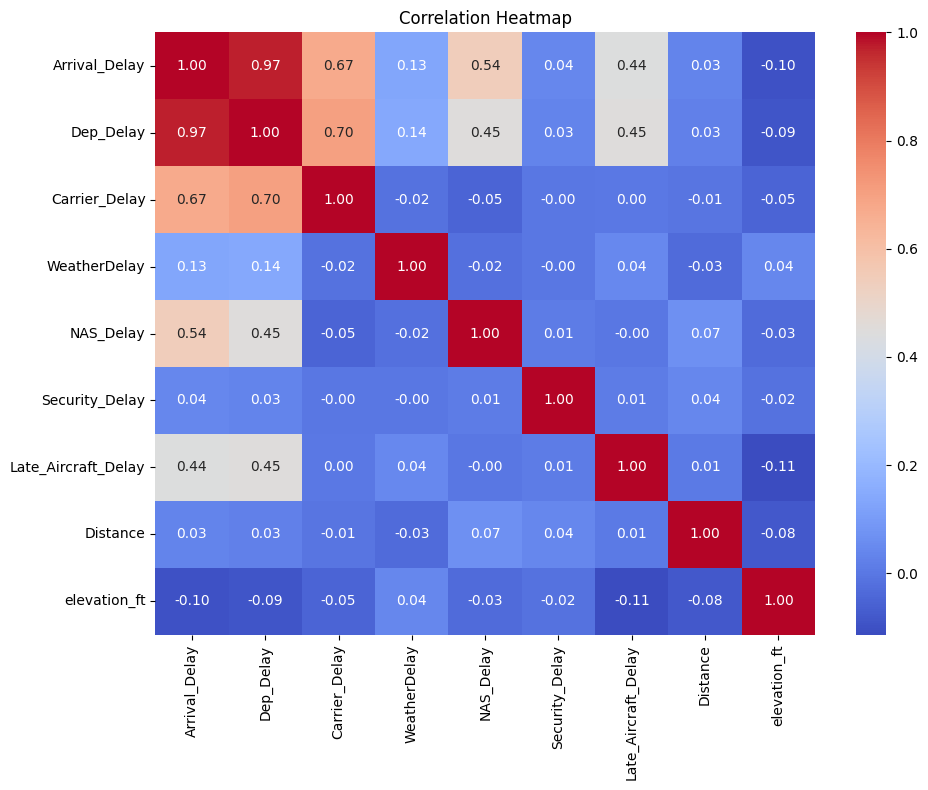

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Arrival_Delay', 'Dep_Delay', 'Carrier_Delay',
        'WeatherDelay', 'NAS_Delay', 'Security_Delay',
        'Late_Aircraft_Delay', 'Distance', 'elevation_ft']

corr = merged_df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

  *Note that very strong relationships :
 Arrival_Delay ↔ Dep_Delay = 0.97  
 This means that if the departure is delayed, the arrival time will automatically be affected.
  
  *Note that strong relationships :

Arrival_Delay ↔ Carrier_Delay = 0.67
Dep_Delay     ↔ Carrier_Delay = 0.70
Arrival_Delay ↔ NAS_Delay     = 0.54
The airline and the air system have a significant impacton on delays.

*Note that weak relationships:
Arrival_Delay ↔ WeatherDelay  = 0.13
Arrival_Delay ↔ Security_Delay = 0.04
Weather and security have a minimal, almost negligible, impact on delays.






Visualizations

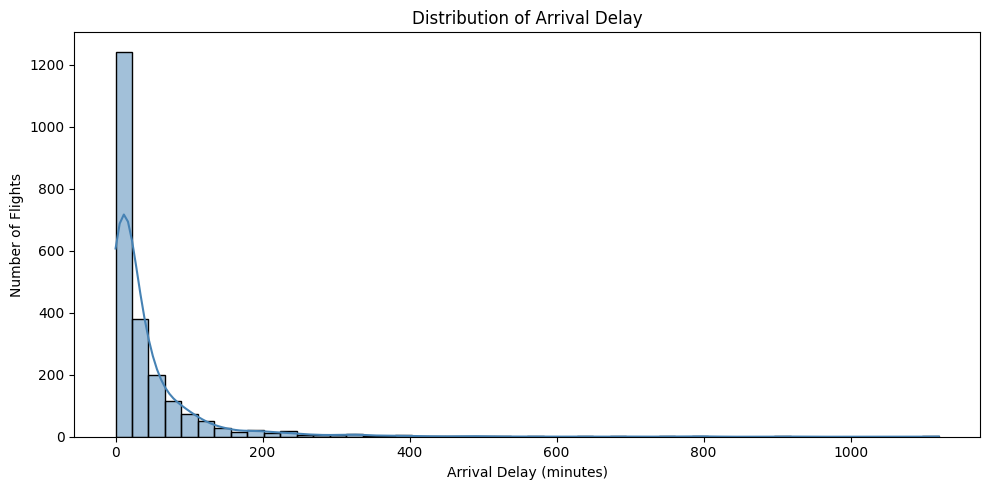

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(merged_df['Arrival_Delay'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Arrival Delay')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

This graph illustrates the delay distribution. Notice that the graph is right-skeywed, meaning most flights are delayed, but only slightly, while a few flights are significantly delayed. Since the graph is right-skeywed, this indicates that the mean is greater than the median. The tail of the graph extends to the right, suggesting the presence of anomalous flights. This affects the mean, raising it, but it doesn't affect the median. Note the high dispersion between the values. This means that the std (standard) value, compared to the mean, has a significant difference. For example, if someone doesn't book a flight, they could be delayed by 5 minutes or even 1000 minutes. Delays are unpredictable, and flights become irregular, which is detrimental to travelers.

/tmp/ipykernel_726/2753593753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.index, y=top_airports.values, palette='Reds_r')


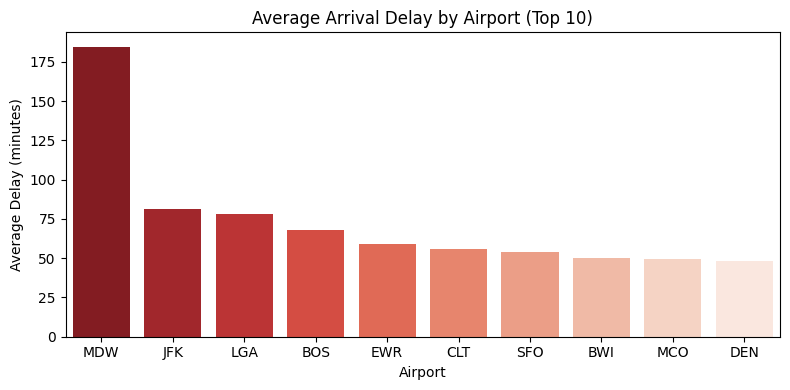

In [ ]:
plt.figure(figsize=(8, 4))
top_airports = merged_df.groupby('Origin_Airport')['Arrival_Delay'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_airports.index, y=top_airports.values, palette='Reds_r')
plt.title('Average Arrival Delay by Airport (Top 10)')
plt.xlabel('Airport')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

This graph explains the delay caused by the airport itself. Here, I compared the average delay of more than 10 airports that experience delays. Notice from the graph that it is right-skeyed. This means that mean > mean, meaning there are outliers with high values ​​that affected the average value. Notice MDW's delay of more than 175 minutes. This means it is an outlier. Notice the difference between it and JFK = 80, and the difference between them = 104. This is a large gap because the delay results of the other airports are almost similar to each other. Also, the difference between MDW and JFK is very large and fragile, which shows that the dispersion is high between airports, meaning that the delay is not guaranteed between airports, and this affects subsequent flights

/tmp/ipykernel_726/558559772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_delay.index, y=weekday_delay.values, palette='Blues_r')


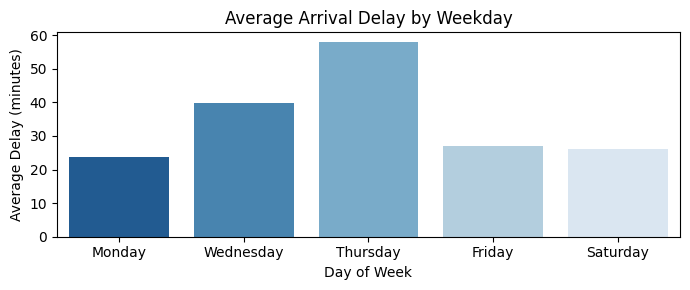

In [ ]:
plt.figure(figsize=(7, 3))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_delay = merged_df.groupby('Weekday_Name')['Arrival_Delay'].mean().reindex(weekday_order).dropna()
sns.barplot(x=weekday_delay.index, y=weekday_delay.values, palette='Blues_r')
plt.title('Average Arrival Delay by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

This graph shows weekly delays, meaning the delays that occur each day of the week. Thursday has an average delay of 60 minutes, the highest rate and the worst delay. The time difference between Thursday and Saturday is 34 minutes, a low rate indicating minimal disruption. This means that delays are expected and reasonable. Thursday is considered the most outlier day compared to the other days... because the average delay on other days ranges between 24 and 27 minutes, while Thursday averages 60 minutes. This difference is significant, and the pattern is not symmetrical.

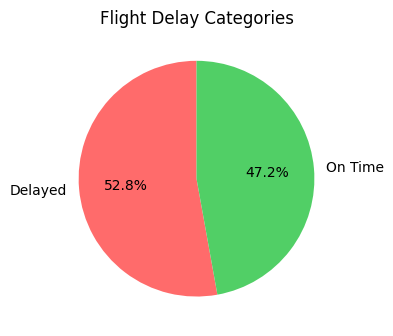

In [ ]:
plt.figure(figsize=(4, 4))
merged_df['Delay_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ff6b6b', '#51cf66'],
    startangle=90
)
plt.title('Flight Delay Categories')
plt.ylabel('')
plt.tight_layout()
plt.show()

This graph shows the percentage of delayed and on-time flights out of 2,203 flights. Note that 52.8% of the flights were delayed, and 47.2% arrived on time. This means that more than half of the flights were delayed; for every two flights, one was delayed or considered delayed.

/tmp/ipykernel_726/2234409544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weekday_Name', y='Arrival_Delay',


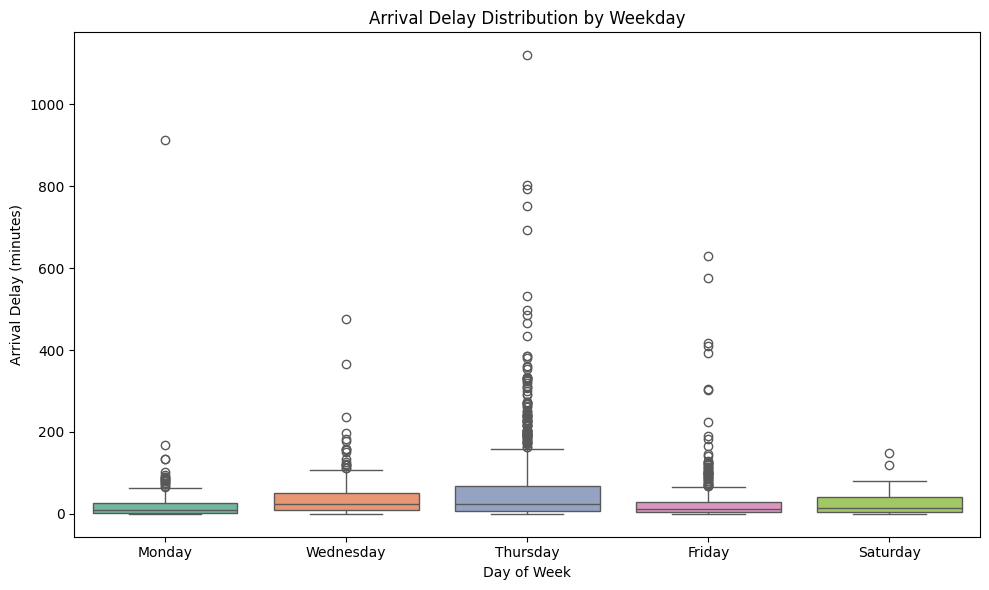

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weekday_Name', y='Arrival_Delay',
            data=merged_df,
            order=['Monday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'],
            palette='Set2')
plt.title('Arrival Delay Distribution by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

This graph shows the outliers as points above the line affected by the event. Note the duration of the event since Thursday. The values ​​show a difference, and the dividing line inside the box represents the median.

In [ ]:
plt.figure(figsize=(6, 3))
delay_causes = merged_df[['Carrier_Delay', 'WeatherDelay',
                           'NAS_Delay', 'Security_Delay',
                           'Late_Aircraft_Delay']].mean()

sns.barplot(x=delay_causes.index, y=delay_causes.values, palette='Oranges_r')
plt.title('Average Delay by Cause')
plt.xlabel('Delay Cause')
plt.ylabel('Average Minutes')
plt.tight_layout()
plt.show()

This graph illustrates the average causes of delays, showing that National Airspace Delay (NAS_delay) has the highest average of 14 minutes. This indicates that NAS_delay is the most significant factor influencing flight delays. Note also that the highest averages are for NAS_delay, Carrick_delay, and arrival_delay, suggesting that these are the three most important factors affecting delays. The impact of weather security is minimal and rare, almost negligible.